In [ ]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

## Plotting Functionality 

In [ ]:
def load_runs(output_dir, env_id, alg_name, final=False):
    """
    Discover and load all returns.npy files for one algorithm/environment.
    Returns a list of arrays, each shape (N_i, 2): columns [global_step, episodic_return].
    Raises FileNotFoundError if no runs are found.
    """
    if final:
        pattern = os.path.join(output_dir, env_id, alg_name, "final_run", "*", "returns.npy")
    else:
        pattern = os.path.join(output_dir, env_id, alg_name, "*", "returns.npy")
    paths = sorted(glob.glob(pattern))
    print(paths)
    if not paths:
        raise FileNotFoundError(f"No runs found matching: {pattern}")
    print(f"  {alg_name}: found {len(paths)} run(s)")
    return [np.load(p) for p in paths]


def _ema_smooth(values, weight):
    """Exponential moving average. weight=0 means no smoothing."""
    if weight == 0:
        return values
    smoothed, last = [], values[0]
    for v in values:
        last = weight * last + (1 - weight) * v
        smoothed.append(last)
    return np.array(smoothed)


def plot_runs(
    output_dir,
    env_id,
    alg_name,
    label=None,
    color=None,
    smoothing=0.0,
    num_points=300,
    ax=None,
    final=False
):
    """
    Load all seeds for one algorithm and plot mean ± 1 std learning curve.

    Parameters
    ----------
    output_dir : str   Root output directory (e.g. "output" or "../output")
    env_id     : str   Gymnasium environment id (e.g. "HalfCheetah-v4")
    alg_name   : str   Algorithm subdirectory name ("ppo" or "sac")
    label      : str   Legend label; defaults to alg_name.upper()
    color      : str   Matplotlib color string; auto-assigned if None
    smoothing  : float EMA weight in [0, 1). 0 = no smoothing, 0.9 = heavy smoothing
    num_points : int   Number of evenly-spaced x-axis points for interpolation
    ax         : matplotlib Axes object; creates a new figure if None

    Returns
    -------
    ax : the Axes object (for chaining / further customisation)
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    if label is None:
        label = alg_name.upper()

    runs = load_runs(output_dir, env_id, alg_name, final)

    # Determine common x-axis: from the latest first-step to the earliest last-step
    x_min = max(r[0, 0]  for r in runs)
    x_max = min(r[-1, 0] for r in runs)
    if x_min >= x_max:
        raise ValueError(
            f"Runs for {alg_name} have no overlapping step range. "
            "Check that all seeds completed at least one episode."
        )
    steps = np.linspace(x_min, x_max, num_points)

    # Smooth each seed, then interpolate onto the common axis
    interp = np.stack([
        np.interp(steps, r[:, 0], _ema_smooth(r[:, 1], smoothing))
        for r in runs
    ])  # shape: (num_seeds, num_points)

    mean = interp.mean(axis=0)
    std  = interp.std(axis=0)

    line, = ax.plot(steps, mean, label=label, color=color, linewidth=1.8)
    c = line.get_color()
    ax.fill_between(steps, mean - std, mean + std, color=c, alpha=0.2)

    return ax

## Plotting PPO 

In [ ]:
# ── Edit these to match your runs ─────────────────────────────────────────────
OUTPUT_DIR = "../output"   # path to the output/ folder relative to this notebook
ENV_ID     = "HalfCheetah-v4" # Change to your chosen environments
SMOOTHING  = 0.9           # EMA weight: 0 = raw data, 0.9 = smooth
# ──────────────────────────────────────────────────────────────────────────────

['../output/HalfCheetah-v4/ppo/final_run/seed1/returns.npy', '../output/HalfCheetah-v4/ppo/final_run/seed2/returns.npy', '../output/HalfCheetah-v4/ppo/final_run/seed3/returns.npy']
  ppo: found 3 run(s)


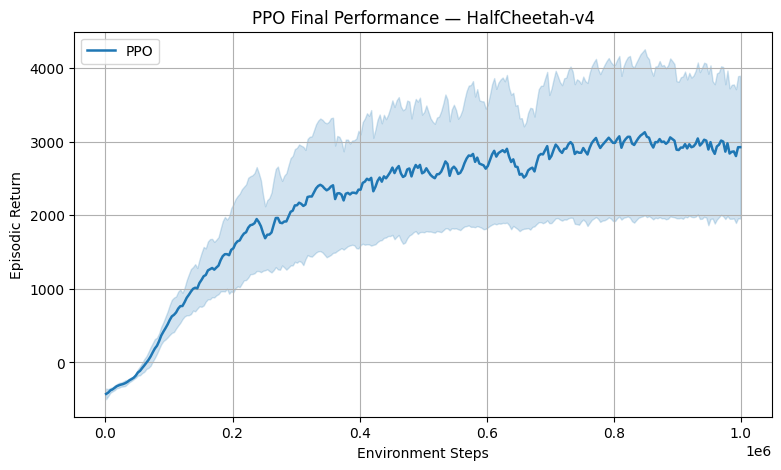

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

plot_runs(
    output_dir="../output",
    env_id="HalfCheetah-v4",
    alg_name="ppo",
    smoothing=0.9,
    ax=ax,
    final=True
)

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Episodic Return")
ax.set_title("PPO Final Performance — HalfCheetah-v4")
ax.legend()
ax.grid(True)

plt.show()

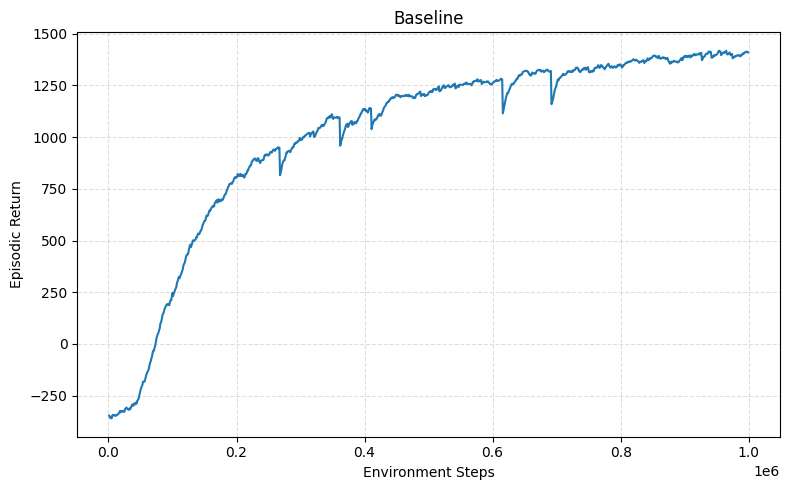

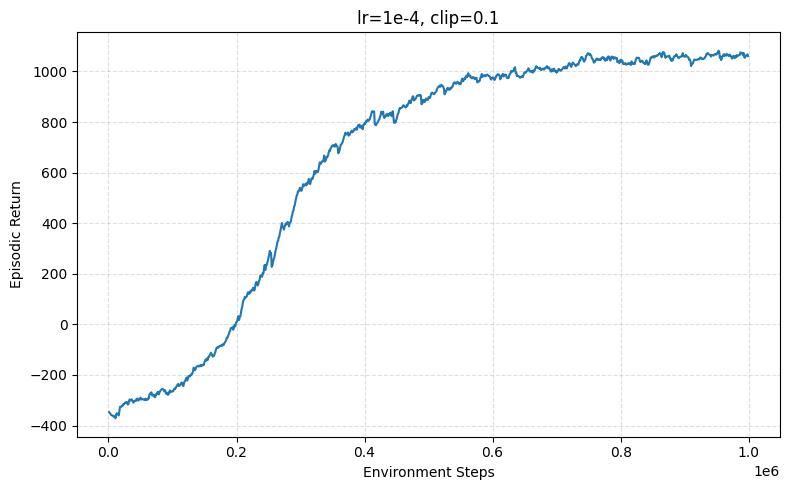

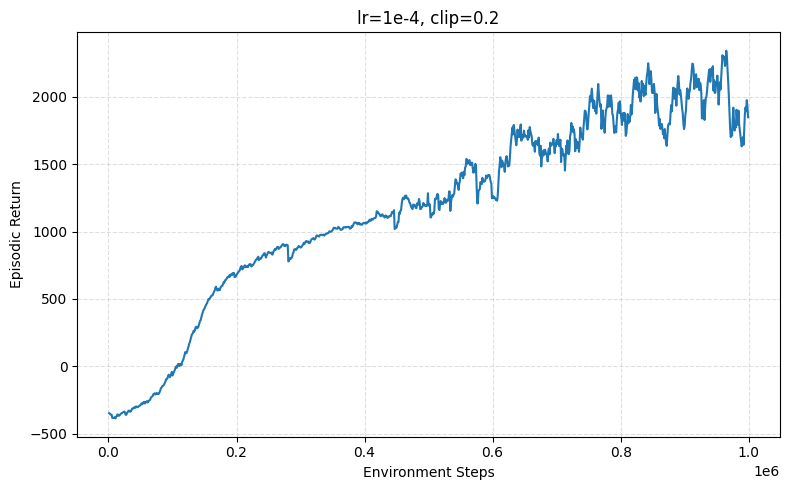

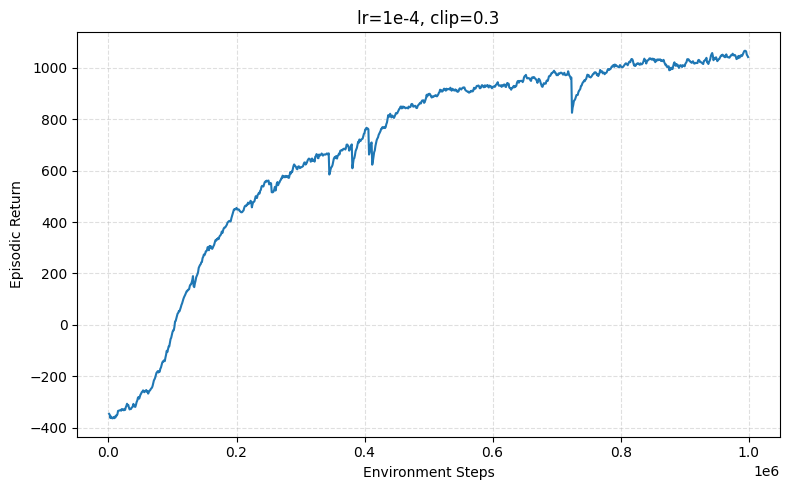

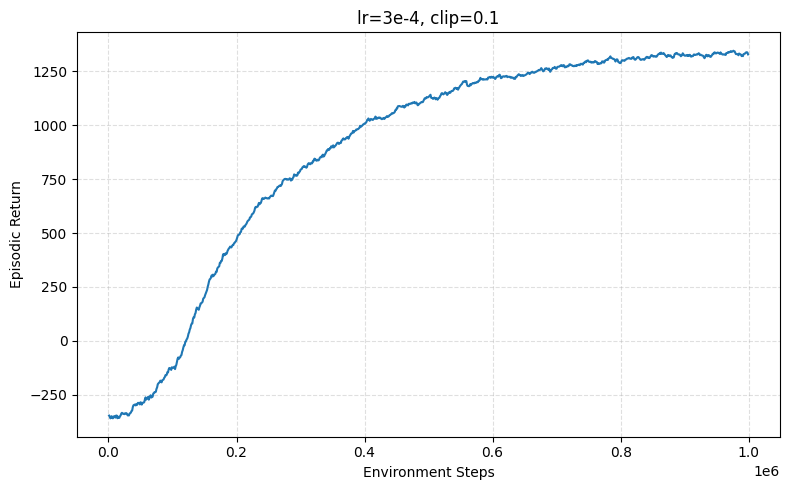

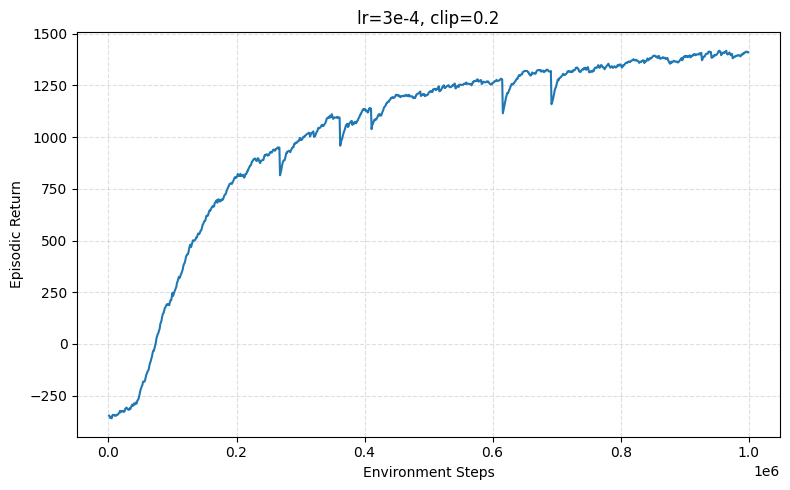

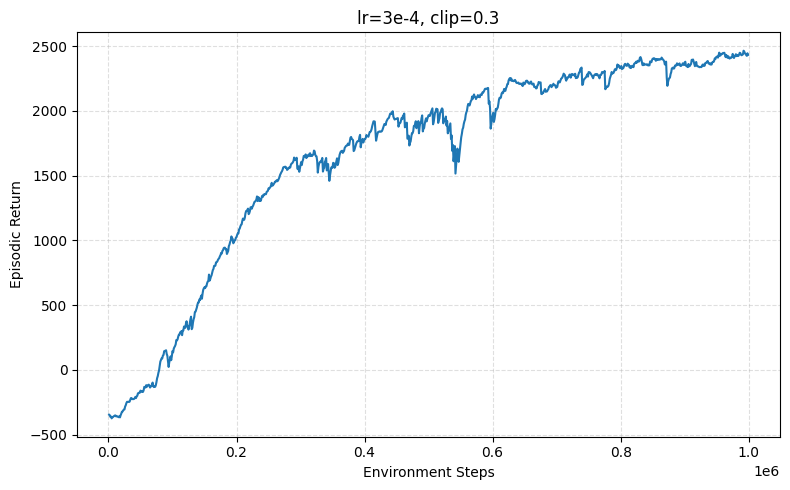

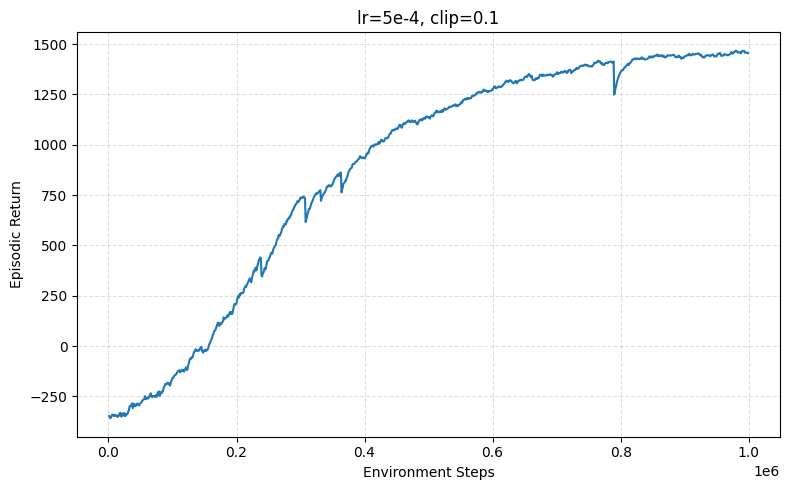

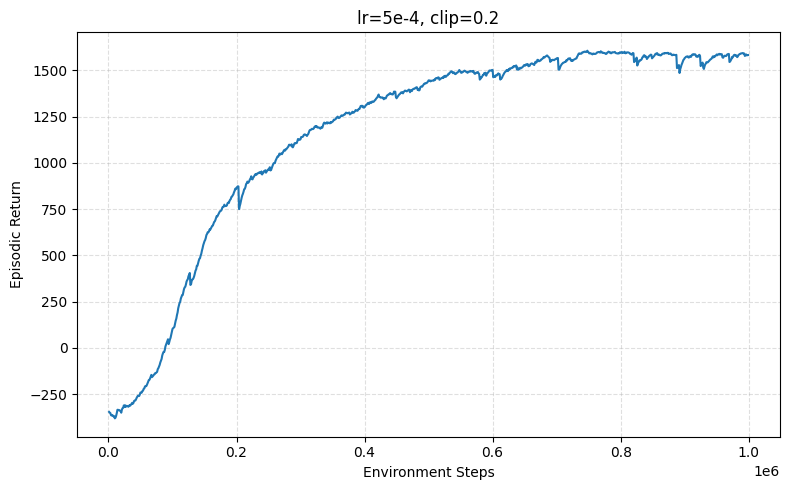

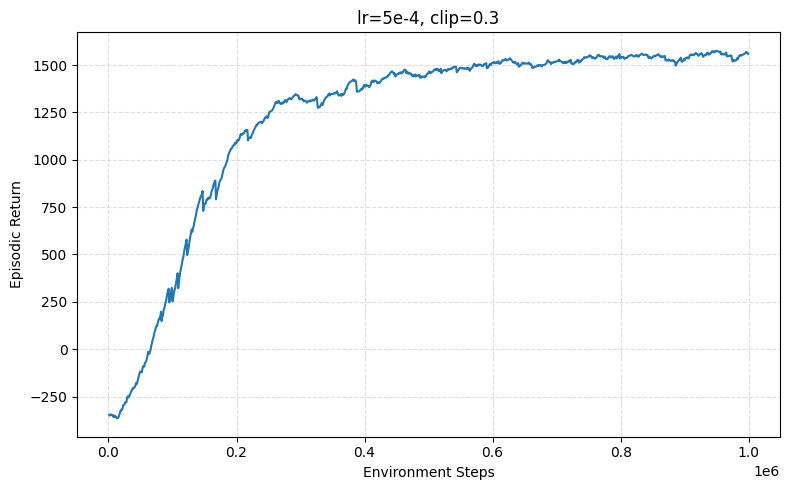

In [ ]:
# Useful for quick inspection of one algorithm
# fig, ax = plt.subplots(figsize=(8, 5))
# plot_runs(OUTPUT_DIR, ENV_ID, "ppo", smoothing=SMOOTHING, ax=ax)
# ax.set_xlabel("Environment Steps")
# ax.set_ylabel("Episodic Return")
# ax.set_title(f"PPO — {ENV_ID}")
# ax.legend()
# ax.grid(True, linestyle="--", alpha=0.4)
# plt.tight_layout()
# plt.show()


run_files = sorted(glob.glob(f"{OUTPUT_DIR}/{ENV_ID}/ppo/*/returns.npy"))

titles = [
    "lr=1e-4, clip=0.1",
    "lr=1e-4, clip=0.2",
    "lr=1e-4, clip=0.3",
    "lr=3e-4, clip=0.1",
    "lr=3e-4, clip=0.2",
    "lr=3e-4, clip=0.3",
    "lr=5e-4, clip=0.1",
    "lr=5e-4, clip=0.2",
    "lr=5e-4, clip=0.3"
]

# 先画 baseline
baseline_file = run_files[0]
data = np.load(baseline_file)

steps = data[:, 0]
returns = data[:, 1]

smoothed = []
s = returns[0]
for r in returns:
    s = SMOOTHING * s + (1 - SMOOTHING) * r
    smoothed.append(s)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, smoothed)
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Episodic Return")
ax.set_title("Baseline")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# 再画后面9个调参 run
tuning_files = run_files[1:]

for i, file in enumerate(tuning_files):
    data = np.load(file)
    steps = data[:, 0]
    returns = data[:, 1]

    smoothed = []
    s = returns[0]
    for r in returns:
        s = SMOOTHING * s + (1 - SMOOTHING) * r
        smoothed.append(s)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, smoothed)

    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Episodic Return")
    ax.set_title(titles[i])
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

## Plotting SAC

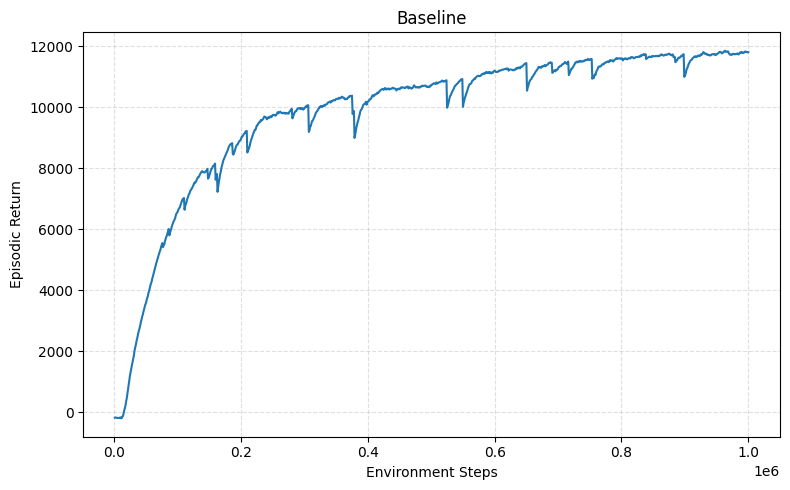

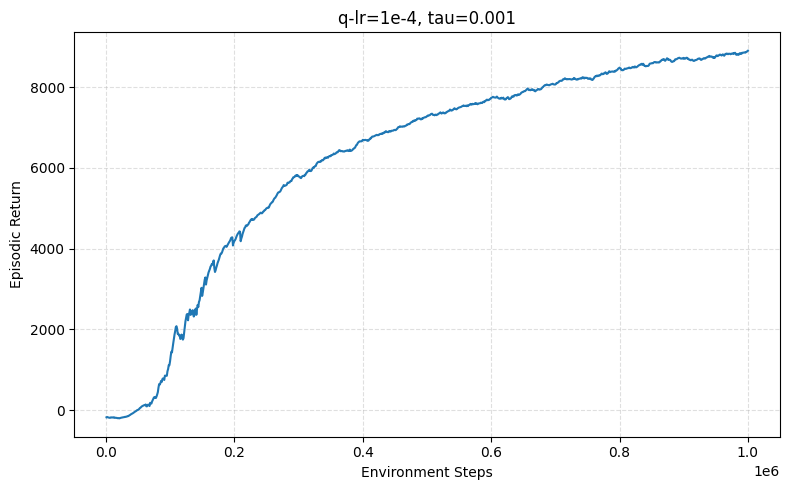

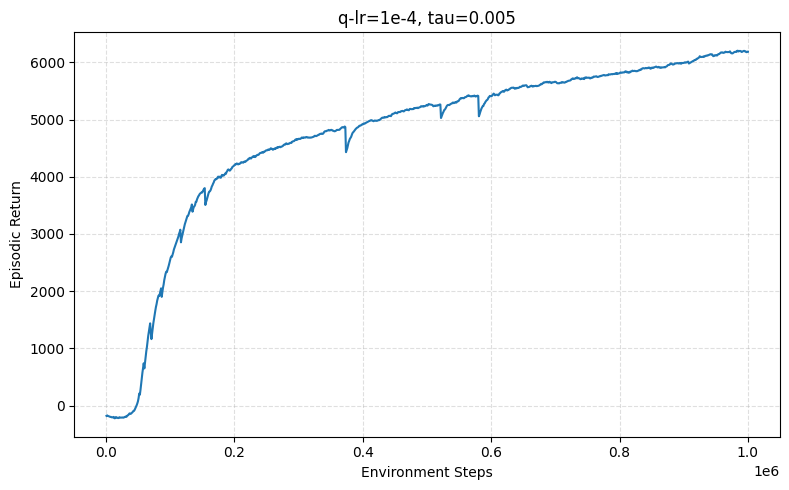

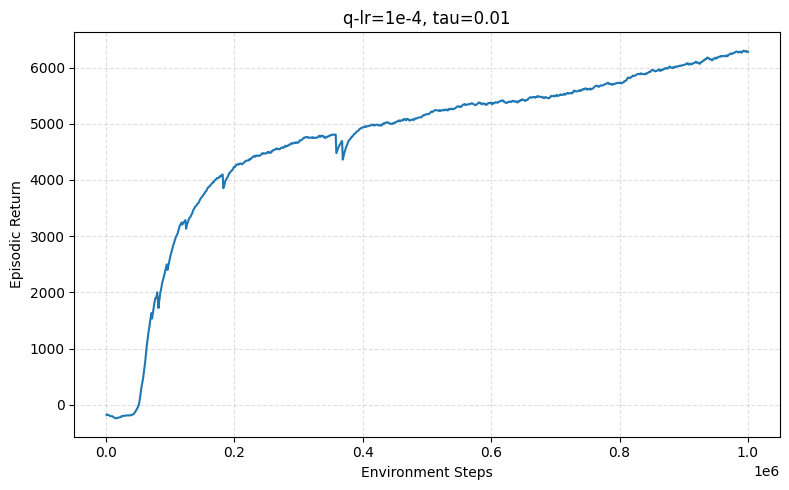

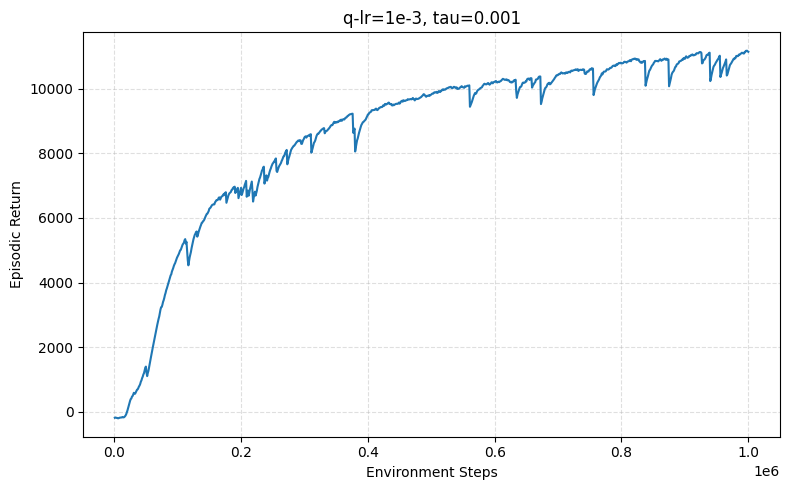

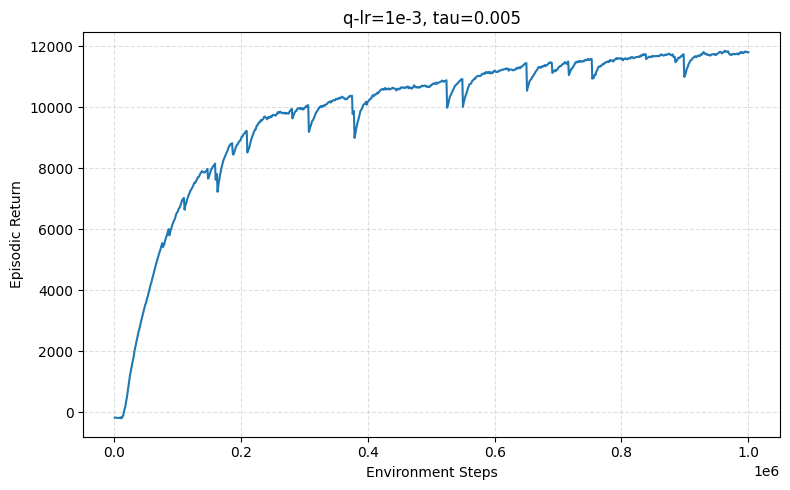

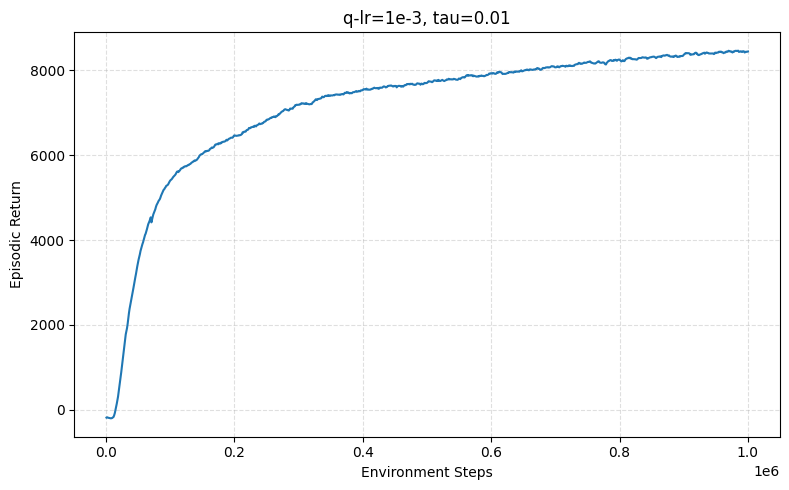

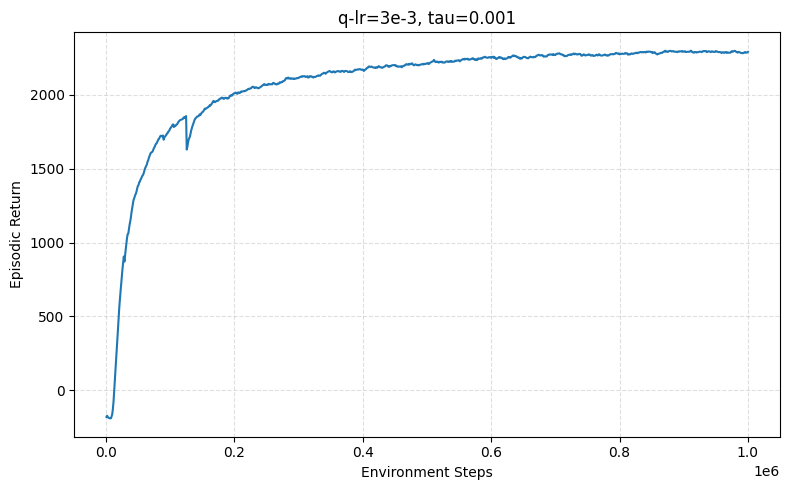

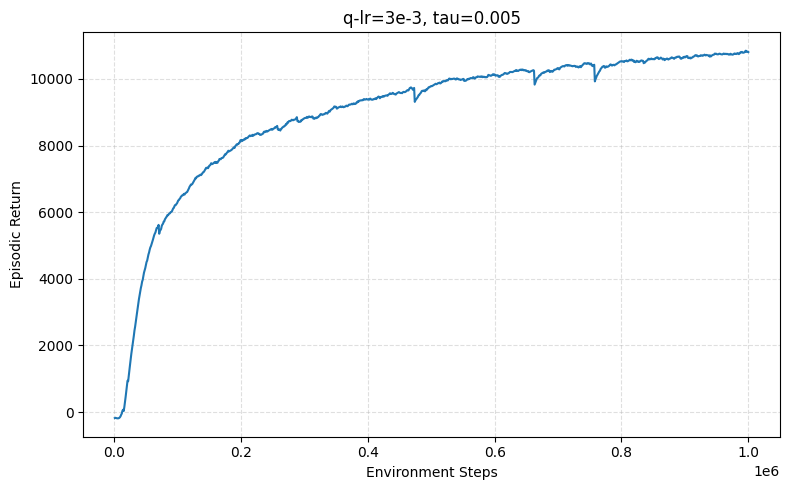

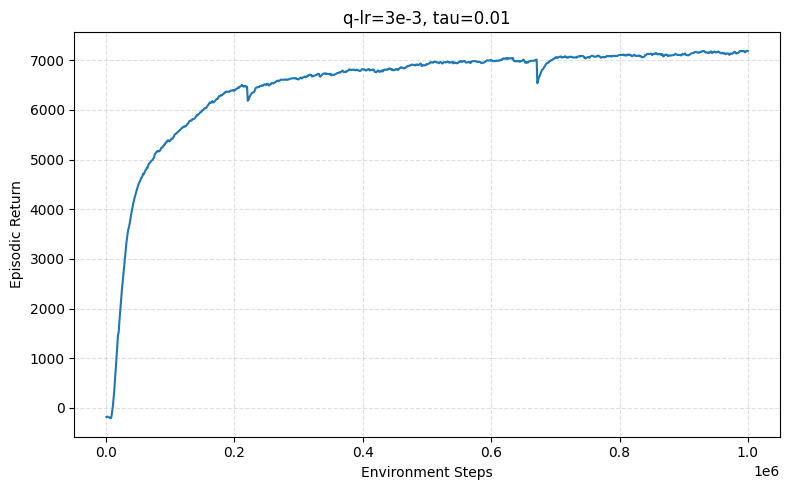

In [ ]:
# # Useful for quick inspection of one algorithm
# fig, ax = plt.subplots(figsize=(8, 5))
# plot_runs(OUTPUT_DIR, ENV_ID, "sac", smoothing=SMOOTHING, ax=ax)
# ax.set_xlabel("Environment Steps"); ax.set_ylabel("Episodic Return")
# ax.set_title(f"SAC — {ENV_ID}"); ax.legend(); ax.grid(True, linestyle="--", alpha=0.4)
# plt.tight_layout(); plt.show()


# Useful for quick inspection of one algorithm
# fig, ax = plt.subplots(figsize=(8, 5))
# plot_runs(OUTPUT_DIR, ENV_ID, "sac", smoothing=SMOOTHING, ax=ax)
# ax.set_xlabel("Environment Steps")
# ax.set_ylabel("Episodic Return")
# ax.set_title(f"SAC — {ENV_ID}")
# ax.legend()
# ax.grid(True, linestyle="--", alpha=0.4)
# plt.tight_layout()
# plt.show()


run_files = sorted(glob.glob(f"{OUTPUT_DIR}/{ENV_ID}/sac/*/returns.npy"))

titles = [
    "q-lr=1e-4, tau=0.001",
    "q-lr=1e-4, tau=0.005",
    "q-lr=1e-4, tau=0.01",
    "q-lr=1e-3, tau=0.001",
    "q-lr=1e-3, tau=0.005",
    "q-lr=1e-3, tau=0.01",
    "q-lr=3e-3, tau=0.001",
    "q-lr=3e-3, tau=0.005",
    "q-lr=3e-3, tau=0.01"
]

# 先画 baseline
baseline_file = run_files[0]
data = np.load(baseline_file)
steps = data[:, 0]
returns = data[:, 1]

smoothed = []
s = returns[0]
for r in returns:
    s = SMOOTHING * s + (1 - SMOOTHING) * r
    smoothed.append(s)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(steps, smoothed)
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Episodic Return")
ax.set_title("Baseline")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# 再画后面9个调参 run
tuning_files = run_files[1:]

for i, file in enumerate(tuning_files):
    data = np.load(file)
    steps = data[:, 0]
    returns = data[:, 1]

    smoothed = []
    s = returns[0]
    for r in returns:
        s = SMOOTHING * s + (1 - SMOOTHING) * r
        smoothed.append(s)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, smoothed)

    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Episodic Return")
    ax.set_title(titles[i])
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

## Plotting PPO vs SAC

In [ ]:
# # ── Edit these to match your runs ─────────────────────────────────────────────
# OUTPUT_DIR = "../agents/output"   # path to the output/ folder relative to this notebook
# ENV_ID     = "HalfCheetah-v4" # Change to your chosen environments
# SMOOTHING  = 0.9           # EMA weight: 0 = raw data, 0.9 = smooth
# # ──────────────────────────────────────────────────────────────────────────────v

In [ ]:
# fig, ax = plt.subplots(figsize=(8, 5))

# plot_runs(OUTPUT_DIR, ENV_ID, "ppo", label="PPO", ax=ax, smoothing=SMOOTHING)
# plot_runs(OUTPUT_DIR, ENV_ID, "sac", label="SAC", ax=ax, smoothing=SMOOTHING)

# ax.set_xlabel("Environment Steps", fontsize=12)
# ax.set_ylabel("Episodic Return",   fontsize=12)
# ax.set_title(f"PPO vs SAC — {ENV_ID}", fontsize=13)
# ax.legend(fontsize=11)
# ax.grid(True, linestyle="--", alpha=0.4)
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# plt.tight_layout()
# plt.savefig(f"{ENV_ID}_learning_curves.pdf", bbox_inches="tight")
# plt.show()

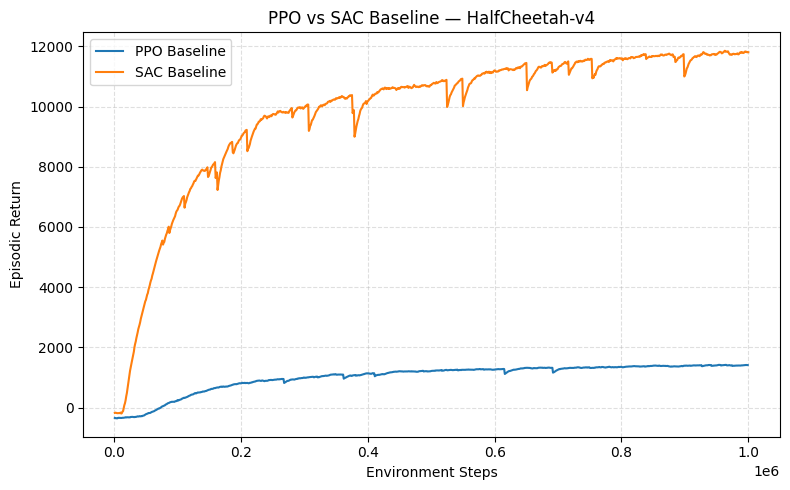

In [ ]:


ppo_files = sorted(glob.glob(f"{OUTPUT_DIR}/{ENV_ID}/ppo/*/returns.npy"))
sac_files = sorted(glob.glob(f"{OUTPUT_DIR}/{ENV_ID}/sac/*/returns.npy"))

# 第一个图 = baseline
ppo_file = ppo_files[0]
sac_file = sac_files[0]

ppo_data = np.load(ppo_file)
sac_data = np.load(sac_file)

ppo_steps, ppo_returns = ppo_data[:, 0], ppo_data[:, 1]
sac_steps, sac_returns = sac_data[:, 0], sac_data[:, 1]

def ema_smooth(values, weight):
    smoothed = []
    s = values[0]
    for v in values:
        s = weight * s + (1 - weight) * v
        smoothed.append(s)
    return np.array(smoothed)

ppo_smoothed = ema_smooth(ppo_returns, SMOOTHING)
sac_smoothed = ema_smooth(sac_returns, SMOOTHING)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ppo_steps, ppo_smoothed, label="PPO Baseline")
ax.plot(sac_steps, sac_smoothed, label="SAC Baseline")

ax.set_xlabel("Environment Steps")
ax.set_ylabel("Episodic Return")
ax.set_title(f"PPO vs SAC Baseline — {ENV_ID}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Plotting Final PPO vs SAC 

In [ ]:
# ── Edit these to match your runs ─────────────────────────────────────────────
OUTPUT_DIR = "../output/"   # path to the output/ folder relative to this notebook
ENV_ID     = "HalfCheetah-v4" # Change to your chosen environments
SMOOTHING  = 0.9           # EMA weight: 0 = raw data, 0.9 = smooth
# ──────────────────────────────────────────────────────────────────────────────v

['../output/HalfCheetah-v4/ppo/final_run/seed1/returns.npy', '../output/HalfCheetah-v4/ppo/final_run/seed2/returns.npy', '../output/HalfCheetah-v4/ppo/final_run/seed3/returns.npy']
  ppo: found 3 run(s)
['../output/HalfCheetah-v4/sac/final_run/seed1/returns.npy', '../output/HalfCheetah-v4/sac/final_run/seed2/returns.npy', '../output/HalfCheetah-v4/sac/final_run/seed3/returns.npy']
  sac: found 3 run(s)


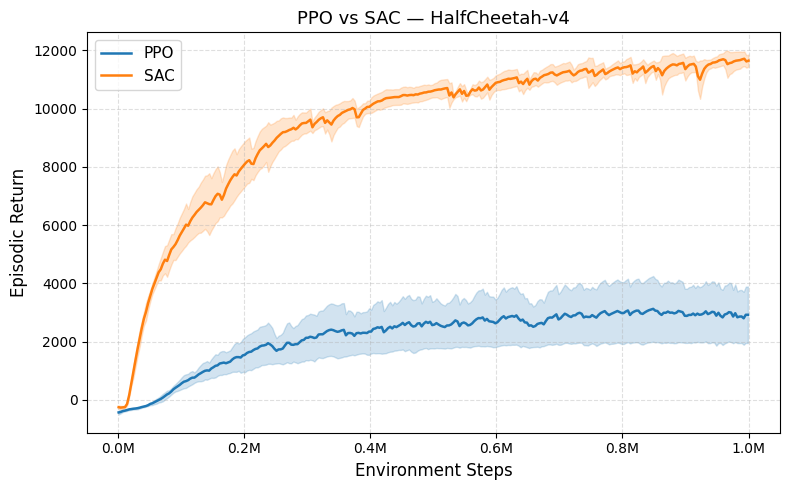

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_runs(OUTPUT_DIR, ENV_ID, "ppo", label="PPO", ax=ax, smoothing=SMOOTHING, final=True)
plot_runs(OUTPUT_DIR, ENV_ID, "sac", label="SAC", ax=ax, smoothing=SMOOTHING, final=True)

ax.set_xlabel("Environment Steps", fontsize=12)
ax.set_ylabel("Episodic Return",   fontsize=12)
ax.set_title(f"PPO vs SAC — {ENV_ID}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(f"{ENV_ID}_learning_curves.pdf", bbox_inches="tight")
plt.show()

In [ ]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../output")
ENV_ID = "HalfCheetah-v4"
LAST_K = 10
SMOOTHING = 0.9

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def ema(values, weight=0.9):
    values = np.asarray(values, dtype=float)
    if len(values) == 0 or weight <= 0:
        return values
    out = np.empty_like(values)
    out[0] = values[0]
    for i in range(1, len(values)):
        out[i] = weight * out[i - 1] + (1 - weight) * values[i]
    return out


def load_alg_runs(env_id, alg_name):
    alg_dir = OUTPUT_DIR / env_id / alg_name
    if not alg_dir.exists():
        raise FileNotFoundError(f"Missing directory: {alg_dir}")

    runs = []
    for run_dir in sorted(alg_dir.iterdir()):
        if not run_dir.is_dir():
            continue

        config_path = run_dir / "config.yaml"
        returns_path = run_dir / "returns.npy"
        if not config_path.exists() or not returns_path.exists():
            continue

        with open(config_path, "r") as f:
            cfg = yaml.safe_load(f)

        arr = np.load(returns_path, allow_pickle=True)
        if len(arr) == 0:
            continue

        steps = np.asarray(arr[:, 0], dtype=float)
        returns = np.asarray(arr[:, 1], dtype=float)

        row = {
            "alg": alg_name,
            "run_dir": run_dir.name,
            "path": str(run_dir),
            "seed": cfg.get("seed"),
            "total_timesteps": cfg.get("total_timesteps"),
            "last_k_mean": float(np.mean(returns[-LAST_K:])),
            "last_k_std": float(np.std(returns[-LAST_K:])),
            "final_return": float(returns[-1]),
            "num_episodes": int(len(returns)),
            "steps": steps,
            "returns": returns,
            "smoothed_returns": ema(returns, SMOOTHING),
            "config": cfg,
        }

        if alg_name == "ppo":
            row["param1_name"] = "learning_rate"
            row["param1"] = cfg.get("learning_rate")
            row["param2_name"] = "clip_coef"
            row["param2"] = cfg.get("clip_coef")
            row["label"] = f"lr={cfg.get('learning_rate')}, clip={cfg.get('clip_coef')}"
            row["is_baseline"] = (
                cfg.get("learning_rate") == 3e-4
                and cfg.get("clip_coef") == 0.2
            )
        elif alg_name == "sac":
            row["param1_name"] = "policy_lr"
            row["param1"] = cfg.get("policy_lr")
            row["param2_name"] = "batch_size"
            row["param2"] = cfg.get("batch_size")
            row["label"] = f"policy_lr={cfg.get('policy_lr')}, batch={cfg.get('batch_size')}"
            row["is_baseline"] = (
                cfg.get("policy_lr") == 3e-4
                and cfg.get("batch_size") == 256
            )
        else:
            raise ValueError(f"Unsupported algorithm: {alg_name}")

        runs.append(row)

    if not runs:
        raise FileNotFoundError(f"No valid runs found under {alg_dir}")

    df = pd.DataFrame(runs).sort_values(
        ["last_k_mean", "final_return"], ascending=False
    ).reset_index(drop=True)
    return df


def display_summary(df, title):
    cols = [
        "run_dir",
        "label",
        "last_k_mean",
        "last_k_std",
        "final_return",
        "num_episodes",
        "is_baseline",
    ]
    print(f"\n{title}")
    display(df[cols].copy())


def plot_grid_curves(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    for _, row in df.iterrows():
        ax.plot(row["steps"], row["smoothed_returns"], label=row["label"], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Episodic Return")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_heatmap(df, title):
    pivot = df.pivot_table(
        index="param1",
        columns="param2",
        values="last_k_mean",
        aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(x) for x in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(y) for y in pivot.index])

    ax.set_xlabel(df["param2_name"].iloc[0])
    ax.set_ylabel(df["param1_name"].iloc[0])
    ax.set_title(title)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", color="white")

    plt.colorbar(im, ax=ax, label=f"Mean of last {LAST_K} returns")
    plt.tight_layout()
    plt.show()


def plot_baseline_vs_best(df, title):
    best = df.iloc[0]

    baseline_df = df[df["is_baseline"]]
    if len(baseline_df) > 0:
        baseline = baseline_df.iloc[0]
    else:
        baseline = df.iloc[1]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        baseline["steps"],
        baseline["smoothed_returns"],
        label=f"Baseline: {baseline['label']}",
        linewidth=2,
    )
    ax.plot(
        best["steps"],
        best["smoothed_returns"],
        label=f"Best tuned: {best['label']}",
        linewidth=2,
    )
    ax.set_title(title)
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Episodic Return")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Baseline metrics:")
    display(pd.DataFrame([baseline])[["label", "last_k_mean", "last_k_std", "final_return"]])

    print("Best tuned metrics:")
    display(pd.DataFrame([best])[["label", "last_k_mean", "last_k_std", "final_return"]])


# Load results
ppo_df = load_alg_runs(ENV_ID, "ppo")
sac_df = load_alg_runs(ENV_ID, "sac")

# Show ranking tables
display_summary(ppo_df, f"PPO runs on {ENV_ID}")
display_summary(sac_df, f"SAC runs on {ENV_ID}")

# Plot all curves
plot_grid_curves(ppo_df, f"PPO Grid Search Curves - {ENV_ID}")
plot_grid_curves(sac_df, f"SAC Grid Search Curves - {ENV_ID}")

# Heatmaps
plot_heatmap(ppo_df, f"PPO Heatmap - Mean of Last {LAST_K} Returns")
plot_heatmap(sac_df, f"SAC Heatmap - Mean of Last {LAST_K} Returns")

# Baseline vs tuned
plot_baseline_vs_best(ppo_df, f"PPO Baseline vs Best Tuned - {ENV_ID}")
plot_baseline_vs_best(sac_df, f"SAC Baseline vs Best Tuned - {ENV_ID}")